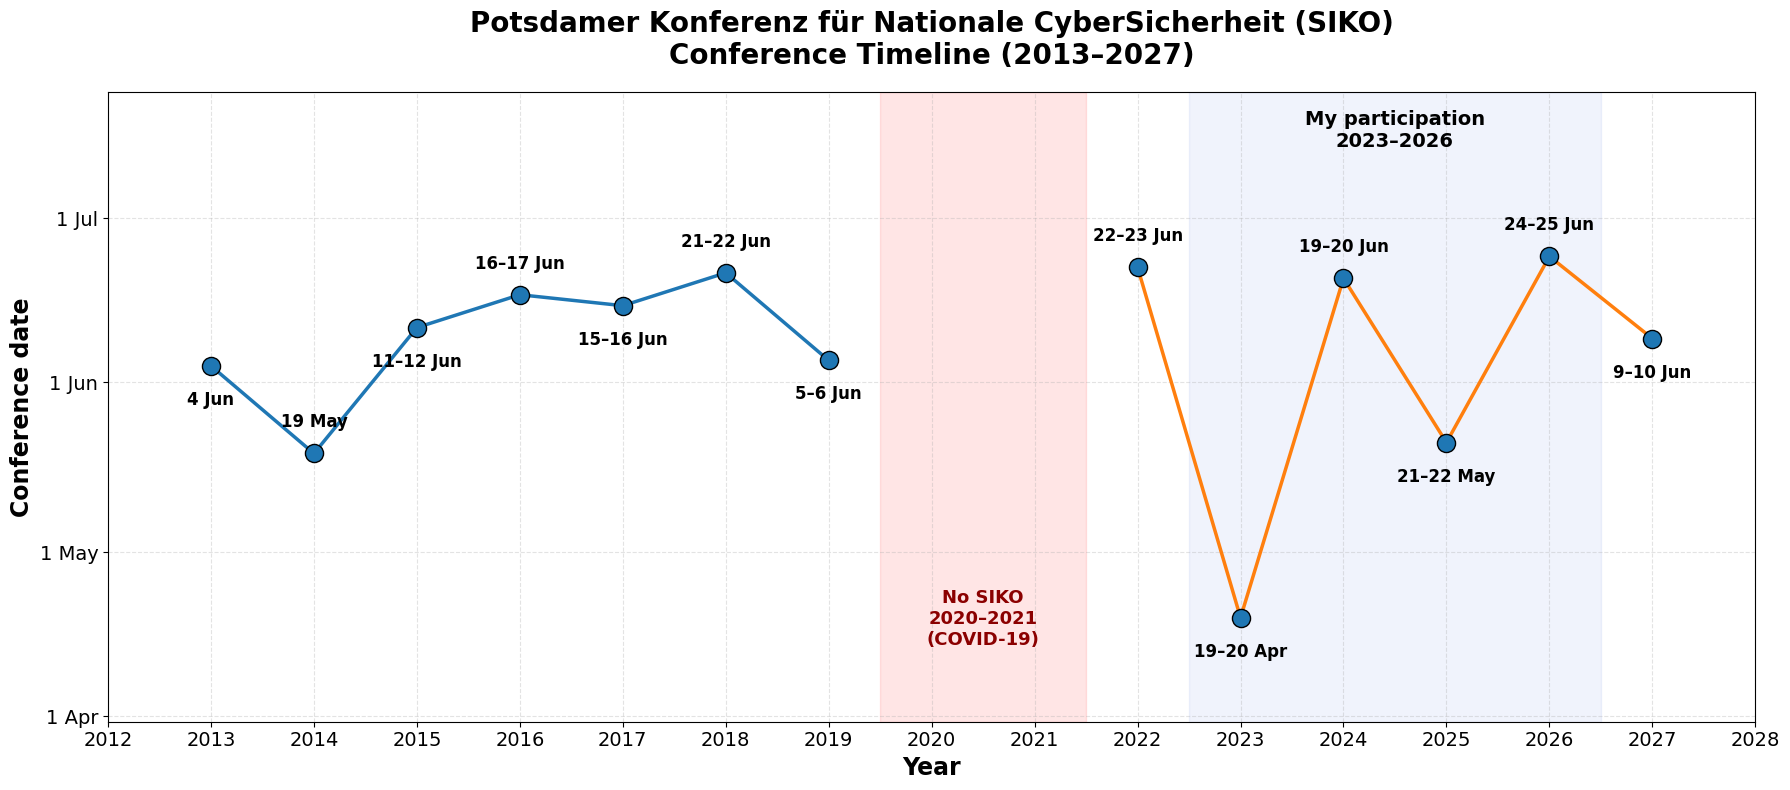

In [5]:
import matplotlib.pyplot as plt
from datetime import datetime

# ============================================================
# SIKO Conference Timeline (2013–2027)
# ============================================================

# First day of each conference
events = {
    2013: ("2013-06-04", "4 Jun"),
    2014: ("2014-05-19", "19 May"),
    2015: ("2015-06-11", "11–12 Jun"),
    2016: ("2016-06-16", "16–17 Jun"),
    2017: ("2017-06-15", "15–16 Jun"),
    2018: ("2018-06-21", "21–22 Jun"),
    2019: ("2019-06-05", "5–6 Jun"),
    2022: ("2022-06-22", "22–23 Jun"),
    2023: ("2023-04-19", "19–20 Apr"),
    2024: ("2024-06-19", "19–20 Jun"),
    2025: ("2025-05-21", "21–22 May"),
    2026: ("2026-06-24", "24–25 Jun"),
    2027: ("2027-06-09", "9–10 Jun"),
}

years = list(events.keys())

day_of_year = [
    datetime.strptime(events[y][0], "%Y-%m-%d").timetuple().tm_yday
    for y in years
]

# ============================================================
# Figure
# ============================================================

fig, ax = plt.subplots(figsize=(18, 8))

# ============================================================
# Connect timeline
# ============================================================

segment1 = [y for y in years if y <= 2019]
segment2 = [y for y in years if y >= 2022]

ax.plot(
    segment1,
    [datetime.strptime(events[y][0], "%Y-%m-%d").timetuple().tm_yday for y in segment1],
    linewidth=2.5,
)

ax.plot(
    segment2,
    [datetime.strptime(events[y][0], "%Y-%m-%d").timetuple().tm_yday for y in segment2],
    linewidth=2.5,
)

# ============================================================
# Scatter points
# ============================================================

ax.scatter(
    years,
    day_of_year,
    s=170,
    edgecolor="black",
    linewidth=1,
    zorder=3,
)

# ============================================================
# Conference date annotations
# ============================================================

for year, doy in zip(years, day_of_year):

    offset = 16 if year % 2 == 0 else -18

    va = "bottom" if offset > 0 else "top"

    ax.annotate(
        events[year][1],
        (year, doy),
        xytext=(0, offset),
        textcoords="offset points",
        ha="center",
        va=va,
        fontsize=12,
        fontweight="bold",
    )

# ============================================================
# COVID-19 period
# ============================================================

ax.axvspan(
    2019.5,
    2021.5,
    color="red",
    alpha=0.10,
)

ax.text(
    2020.5,
    104,
    "No SIKO\n2020–2021\n(COVID-19)",
    ha="center",
    fontsize=13,
    fontweight="bold",
    color="darkred",
)

# ============================================================
# My participation
# ============================================================

ax.axvspan(
    2022.5,
    2026.5,
    color="royalblue",
    alpha=0.08,
)

ax.text(
    2024.5,
    195,
    "My participation\n2023–2026",
    ha="center",
    fontsize=14,
    fontweight="bold",
)

# ============================================================
# Axis formatting
# ============================================================

month_ticks = [
    datetime(2025, 4, 1).timetuple().tm_yday,
    datetime(2025, 5, 1).timetuple().tm_yday,
    datetime(2025, 6, 1).timetuple().tm_yday,
    datetime(2025, 7, 1).timetuple().tm_yday,
]

ax.set_yticks(month_ticks)

ax.set_yticklabels(
    [
        "1 Apr",
        "1 May",
        "1 Jun",
        "1 Jul",
    ],
    fontsize=14,
)

ax.set_xticks(range(2012, 2029))

ax.tick_params(
    axis="x",
    labelsize=14,
)

ax.tick_params(
    axis="y",
    labelsize=14,
)

# ============================================================
# Labels
# ============================================================

ax.set_xlabel(
    "Year",
    fontsize=17,
    fontweight="bold",
)

ax.set_ylabel(
    "Conference date",
    fontsize=17,
    fontweight="bold",
)

ax.set_title(
    "Potsdamer Konferenz für Nationale CyberSicherheit (SIKO)\nConference Timeline (2013–2027)",
    fontsize=20,
    fontweight="bold",
    pad=20,
)

# ============================================================
# Grid
# ============================================================

ax.grid(
    linestyle="--",
    alpha=0.35,
)

ax.set_xlim(2012, 2028)

ax.set_ylim(90, 205)

# ============================================================
# Save
# ============================================================

plt.tight_layout()

plt.savefig(
    "SIKO_exact_dates_timeline.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()